<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/GradientandXGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Gradient Boosting**
It is a Boosting algorithm where we bring the team of decision trees where each decisions tree's job is to correct the mistakes of the previous ones.

**How it works**: - We are trying to predict a student final exam score.
* First learner attempts: The first model makes a guess (eg. 75 instead of the real 85) -> Error = +10
* Second learner: The next model learns to predict that error (+10)
* Combine: We adjust the first guess using a small part of the second model's correction.
* Repeat: keep adding new models, each fixing what is wrong from before


##**Let's Create the GB from the scratch**

**Classical libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Define my data**

In [ ]:
# We initialized the random state to fix the values
np.random.seed(42)
# We will define the features
x = np.random.rand(100,1) - 0.5 # here i gave 0.5 as noise
# defining my target
y = 3*x[:,0]**2 +0.05 * np.random.randn(100) # we added 0.05 noise (gausian noise) so that model can learn

# y = 3x^2 + e

**Put this data into dataframe**

In [ ]:
df = pd.DataFrame()

In [ ]:
df['X'] = x.reshape(100)
df['Y'] = y

In [ ]:
df

,X,Y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


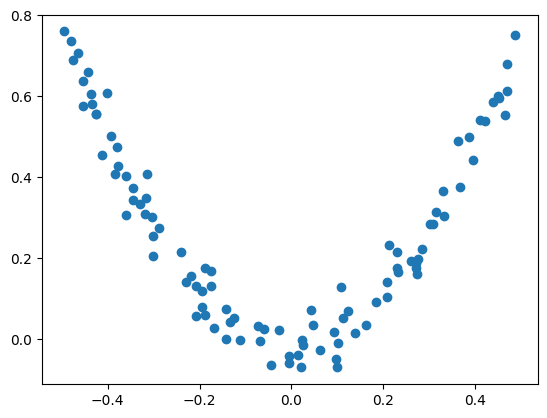

In [ ]:
plt.scatter(df['X'],df['Y'])
plt.show()

**Shape inspection**

In [ ]:
x.shape, y.shape

((100, 1), (100,))

**Let's Build base model**

In [ ]:
df['Pred1'] = df['Y'].mean()

In [ ]:
df.head()

,X,Y,Pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


**Now Evaluate the errors (residuals) `(Actual - Pred1)`**

In [ ]:
df['Residual1'] = df['Y'] - df['Pred1']

In [ ]:
df.head()

,X,Y,Pred1,Residual1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


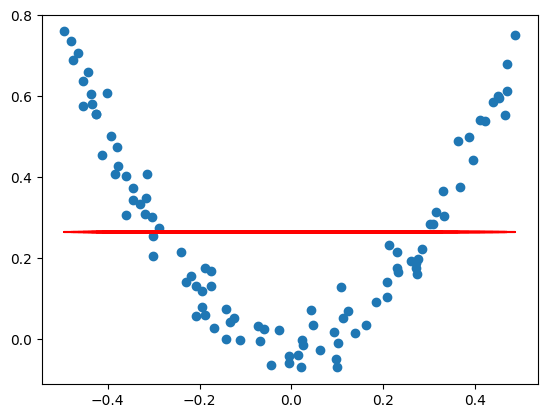

In [ ]:
plt.scatter(df['X'],df['Y'])
plt.plot(df['X'],df['Pred1'], color = 'red')
plt.show()

**Let's Call decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor , plot_tree

**The number of nodes for gradientboosting can be anything, but for better result use nodes between (8-32)**

In [ ]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
tree1.fit(df['X'].values.reshape(100,1), df['Residual1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

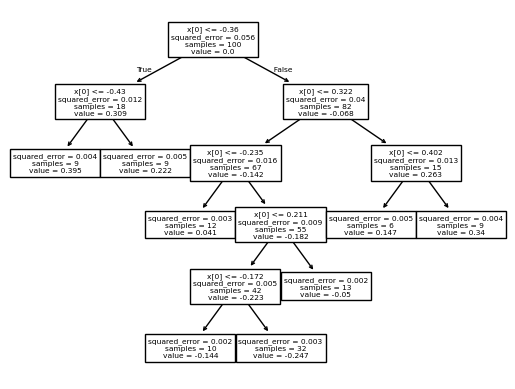

In [ ]:
plot_tree(tree1)
plt.show()

**Genreating a Testing Data**

In [ ]:
x_test = np.linspace(-0.5,0.5,500)

x_test = x_test.reshape(500,1)

In [ ]:
x_test

array([[-0.5       ],
       [-0.49799599],
       [-0.49599198],
       [-0.49398798],
       [-0.49198397],
       [-0.48997996],
       [-0.48797595],
       [-0.48597194],
       [-0.48396794],
       [-0.48196393],
       [-0.47995992],
       [-0.47795591],
       [-0.4759519 ],
       [-0.4739479 ],
       [-0.47194389],
       [-0.46993988],
       [-0.46793587],
       [-0.46593186],
       [-0.46392786],
       [-0.46192385],
       [-0.45991984],
       [-0.45791583],
       [-0.45591182],
       [-0.45390782],
       [-0.45190381],
       [-0.4498998 ],
       [-0.44789579],
       [-0.44589178],
       [-0.44388778],
       [-0.44188377],
       [-0.43987976],
       [-0.43787575],
       [-0.43587174],
       [-0.43386774],
       [-0.43186373],
       [-0.42985972],
       [-0.42785571],
       [-0.4258517 ],
       [-0.4238477 ],
       [-0.42184369],
       [-0.41983968],
       [-0.41783567],
       [-0.41583166],
       [-0.41382766],
       [-0.41182365],
       [-0

**Predict the data records = m1 + m2**

In [ ]:
y_pred = 0.265 + tree1.predict(x_test)

In [ ]:
y_pred

array([0.66045394, 0.66045394, 0.66045394, 0.66045394, 0.66045394,
       0.66045394, 0.66045394, 0.66045394, 0.66045394, 0.66045394,
       0.66045394, 0.66045394, 0.66045394, 0.66045394, 0.66045394,
       0.66045394, 0.66045394, 0.66045394, 0.66045394, 0.66045394,
       0.66045394, 0.66045394, 0.66045394, 0.66045394, 0.66045394,
       0.66045394, 0.66045394, 0.66045394, 0.66045394, 0.66045394,
       0.66045394, 0.66045394, 0.66045394, 0.66045394, 0.66045394,
       0.48733842, 0.48733842, 0.48733842, 0.48733842, 0.48733842,
       0.48733842, 0.48733842, 0.48733842, 0.48733842, 0.48733842,
       0.48733842, 0.48733842, 0.48733842, 0.48733842, 0.48733842,
       0.48733842, 0.48733842, 0.48733842, 0.48733842, 0.48733842,
       0.48733842, 0.48733842, 0.48733842, 0.48733842, 0.48733842,
       0.48733842, 0.48733842, 0.48733842, 0.48733842, 0.48733842,
       0.48733842, 0.48733842, 0.48733842, 0.48733842, 0.48733842,
       0.30550621, 0.30550621, 0.30550621, 0.30550621, 0.30550

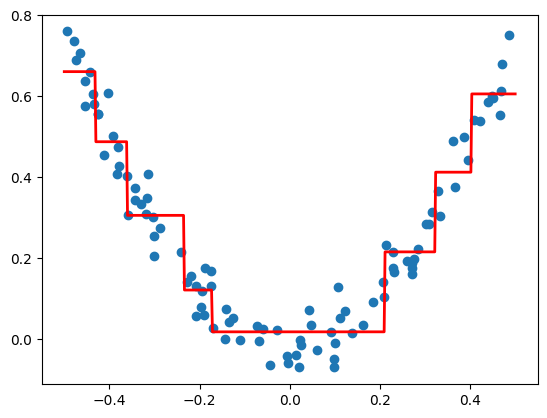

In [ ]:
plt.plot(x_test, y_pred, linewidth =2,color = 'red')
plt.scatter(df['X'],df['Y'])
plt.show()

In [ ]:
df['Pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))

In [ ]:
df.head()

,X,Y,Pred1,Residual1,Pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018319
4,-0.343981,0.343986,0.265458,0.078528,0.305964


**Calculate the residual for model pred2**

In [ ]:
df['Residual2'] = df['Y'] - df['Pred2']

In [ ]:
df.head()

,X,Y,Pred1,Residual1,Pred2,Residual2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022


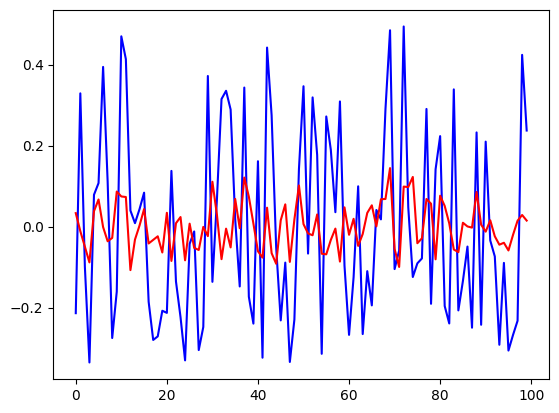

In [ ]:
plt.plot(df['Residual1'], label = 'First Error', color = 'blue')
plt.plot(df['Residual2'],label = 'Second Error', color = 'red')
plt.show()

**Creating tree2/model2**

In [ ]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)

In [ ]:
tree2.fit(df['X'].values.reshape(100,1),df['Residual2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

**updated pred = m1 + m2 + m3 ....**

In [ ]:
y_pred = 0.265458	+ sum(i.predict(x_test.reshape(-1,1)) for i in [tree1,tree2])

In [ ]:
y_pred

array([ 0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.72298721,  0.72298721,  0.72298721,  0.72298721,  0.72298721,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.61125243,  0.61125243,  0.61125243,  0.61125243,  0.61125243,
        0.54390188,  0.54390188,  0.54390188,  0.54390188,  0.54390188,
        0.54390188,  0.54390188,  0.54390188,  0.54390188,  0.54390188,
        0.54390188,  0.54390188,  0.54390188,  0.54390188,  0.54390188,
        0.54390188,  0.54390188,  0.48379813,  0.48379813,  0.48379813,
        0.48379813,  0.48379813,  0.48379813,  0.48379813,  0.48379813,
        0.48379813,  0.48379813,  0.48379813,  0.48379813,  0.48379813,
        0.48379813,  0.48379813,  0.48379813,  0.48379813,  0.48

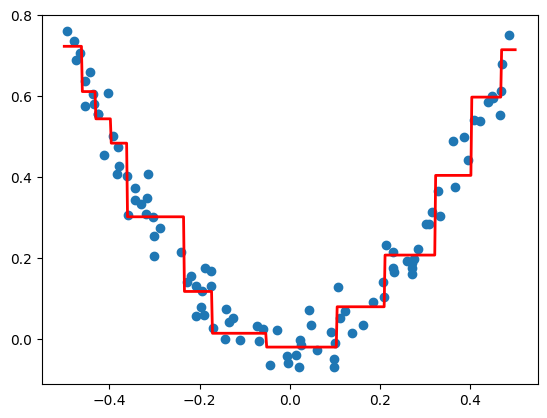

In [ ]:
plt.plot(x_test, y_pred, linewidth = 2, color = 'red')
plt.scatter(df['X'],df['Y'])
plt.show()

**Gradient Boositing Function**
* x = Input variables
* y = Target variables
* number = Number of times, we are going to do the iteration for boosting
* learningRate = How fast or how slow we are going learn
* count = Current Iteration
* model = A list of all the models that we are going to considers
* Temp = Pre defined temp variable

In [ ]:
def gradientBoosting(x,y, number, learningRate, count = 1, model = [], temp = None):

  #  recursion Condition
  if number == 0:
    return
  else:
    if count > 1:
      y = y - model[-1].predict(x) # Residuals
    else:
      temp = y

  # Building Team of models
  regressor = DecisionTreeRegressor(max_depth=5,random_state=32)
  regressor.fit(x,y)

  model.append(regressor)

  dummyTestingData = np.linspace(-0.5,0.5,500)
  y_pred = sum(learningRate * x.predict(dummyTestingData.reshape(-1,1)) for x in model)

  print(f'The updates at the {count} ')

  # Visualizing the updates and the predicted values
  plt.figure()
  plt.plot(dummyTestingData, y_pred, linewidth = 2, color='red')
  plt.plot(x[:,0],temp , 'r.')
  plt.show()

  # Recursion
  gradientBoosting(x,y,number -1, learningRate, count+1, temp= temp)

**Do the implementation**

In [ ]:
np.random.seed(42)
x = np.random.rand(100,1) - 0.5
y = 3*x[:,0]**2 + 0.05 * np.random.randn(100)

Parameters:
* x -> input
* y -> Target
* number -> 5
* learningRate -> 1

The updates at the 1 


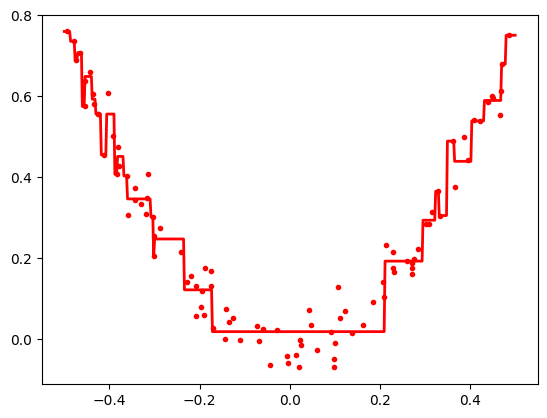

The updates at the 2 


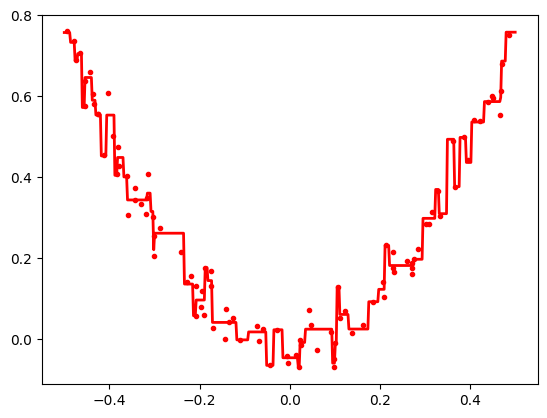

The updates at the 3 


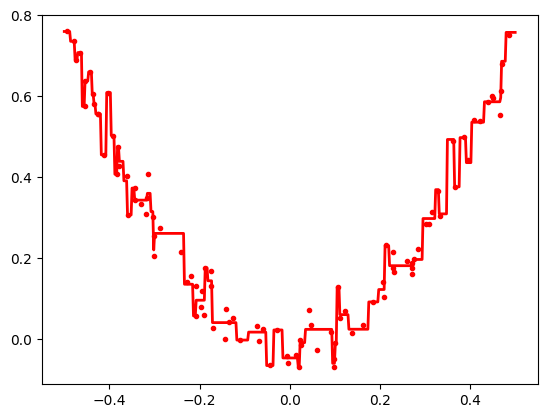

The updates at the 4 


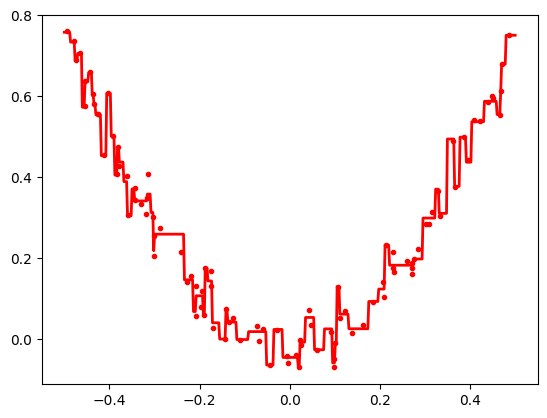

The updates at the 5 


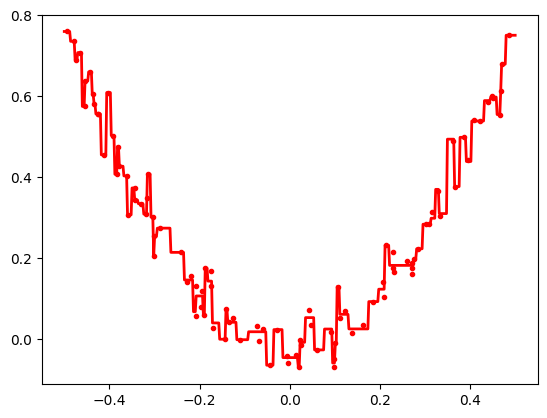

In [ ]:
gradientBoosting(x,y,5,1)

##**XGBoost** (Extreme Gradient Boosting)
It is an advanced version of gradient boosting where we have more smarter Decision trees
* DT of XGB -> It builds decision trees in a clever way which will aim for both accuracy and the simplicity (it is also avoing overfitting)
* It has built in l1 and l2 regularization that stops the model from getting too complicated
* since it use parllel computing, it train the model much quicker as compare to other boosting models
* It can automatically handles the missing values (When do the tree split XGB sends the missing values into the correct direction)
* When XGB finds the best split for the tree, it checks many splits based on feature at the same time by using parllel processing

**Note** -> XGB Parallelize the split finding steps, not the whole boosting process (since trees are still added one after another)

In [ ]:
from xgboost import XGBClassifier as XGB
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

In [ ]:
df = pd.read_csv('/content/diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
x = df.drop('Outcome',axis = 1)
y = df['Outcome']

**Let's Split the data**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state = 1)

In [ ]:
model = XGB()

In [ ]:
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
accuracy_score(y_pred,y_test)

0.75

In [ ]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81       125
           1       0.64      0.66      0.65        67

    accuracy                           0.75       192
   macro avg       0.73      0.73      0.73       192
weighted avg       0.75      0.75      0.75       192



Documentation of XGB: https://xgboost.readthedocs.io/en/stable/

**Important Parameters**
* reg_alpha: For l1 Regularizatin
* reg_lambda: for l2 regularization
* Reg: squarred error
* binary: logistic
* multi: softmax
* multi : softprob
* gamma: more gamma value --> more simple tree

**For randomness in sample data**
* subsample -> Helps for preventing overfitting
* colsample_bytree -> It splits based on the features (adds randomness, reduces overfitting)

**Eval mat**
* logloss
* merror
* mlogloss

